In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

df = pd.read_csv('D:/Semantic-Ecommerce-Recommender/data/raw/amazon_sample.csv')
df_cat = pd.read_csv('D:/Semantic-Ecommerce-Recommender/data/raw/amazon_categories.csv')

print(f"Sample shape: {df.shape}")
print(f"Categories shape: {df_cat.shape}")
df.head()

Sample shape: (8000, 12)
Categories shape: (248, 2)


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,category_name
0,B0C72BBX2K,340-Piece Drywall Anchors and Screws Combo Pac...,https://m.media-amazon.com/images/I/719Vn02sGs...,https://www.amazon.com/dp/B0C72BBX2K,4.6,0,6.90,0.00,154,False,700,NaN
1,B0BKGCPHVH,"Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...",https://m.media-amazon.com/images/I/51lttzoeKl...,https://www.amazon.com/dp/B0BKGCPHVH,4.3,44,7.99,0.00,91,False,0,NaN
2,B08M4BN431,Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...,https://m.media-amazon.com/images/I/716nFovNhS...,https://www.amazon.com/dp/B08M4BN431,4.8,0,189.99,214.99,63,False,0,NaN
3,B097YXFWL4,"Dr. Scholl's Moleskin Padding Strips, 3 Strips...",https://m.media-amazon.com/images/I/81rbkYmbw4...,https://www.amazon.com/dp/B097YXFWL4,4.7,0,5.99,6.66,131,False,3000,NaN
4,B07W3SH69B,COKOHAPPY Halloween Temporary Face Tattoos Mak...,https://m.media-amazon.com/images/I/71ije6pzB-...,https://www.amazon.com/dp/B07W3SH69B,4.3,613,6.99,0.00,48,False,200,NaN


In [2]:
# Drop any existing category_name to avoid duplicate columns, then merge fresh
df = df.drop(columns=['category_name'], errors='ignore')
df = df.merge(df_cat, left_on='category_id', right_on='id', how='left')
df = df.drop(columns=['id'])

print(f"Missing category_name: {df['category_name'].isnull().sum()}")
print(f"Shape: {df.shape}")
print(f"Unique categories: {df['category_name'].nunique()}")
df.head()

Missing category_name: 0
Shape: (8000, 12)
Unique categories: 248


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,category_name
0,B0C72BBX2K,340-Piece Drywall Anchors and Screws Combo Pac...,https://m.media-amazon.com/images/I/719Vn02sGs...,https://www.amazon.com/dp/B0C72BBX2K,4.6,0,6.90,0.00,154,False,700,Fasteners
1,B0BKGCPHVH,"Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...",https://m.media-amazon.com/images/I/51lttzoeKl...,https://www.amazon.com/dp/B0BKGCPHVH,4.3,44,7.99,0.00,91,False,0,Girls' Clothing
2,B08M4BN431,Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...,https://m.media-amazon.com/images/I/716nFovNhS...,https://www.amazon.com/dp/B08M4BN431,4.8,0,189.99,214.99,63,False,0,Computer Components
3,B097YXFWL4,"Dr. Scholl's Moleskin Padding Strips, 3 Strips...",https://m.media-amazon.com/images/I/81rbkYmbw4...,https://www.amazon.com/dp/B097YXFWL4,4.7,0,5.99,6.66,131,False,3000,Health Care Products
4,B07W3SH69B,COKOHAPPY Halloween Temporary Face Tattoos Mak...,https://m.media-amazon.com/images/I/71ije6pzB-...,https://www.amazon.com/dp/B07W3SH69B,4.3,613,6.99,0.00,48,False,200,Makeup


In [16]:
print(f"Missing category_name: {df['category_name'].isnull().sum()}")
print(f"\nSample rows with missing category:")
df[df['category_name'].isnull()][['asin', 'title', 'category_id']].head(10)

Missing category_name: 7886

Sample rows with missing category:


,asin,title,category_id
0,B0C72BBX2K,340-Piece Drywall Anchors and Screws Combo Pac...,154
1,B0BKGCPHVH,"Girl Tutu Skirts,3Layers Tulle Sequin Star Bal...",91
2,B08M4BN431,Corsair iCUE 5000X RGB Tempered Glass Mid-Towe...,63
3,B097YXFWL4,"Dr. Scholl's Moleskin Padding Strips, 3 Strips...",131
4,B07W3SH69B,COKOHAPPY Halloween Temporary Face Tattoos Mak...,48
5,B07L3Y9DBH,Girls Fashion PU Leather Motorcycle Jacket Chi...,91
6,B09NSCJC9W,Google Nest WiFi - AC2200 (2nd Generation) Rou...,81
7,B00PA4AG7S,Boys' P0425/S Polarized Rectangular Sunglasses...,87
8,B07YJFH22W,"MATEIN Travel Laptop Backpack for Men, Water R...",65
9,B0CDS4W8FZ,6Pcs Halloween Light Up Pumpkin Necklace Hallo...,225


In [3]:
df.to_csv('D:/Semantic-Ecommerce-Recommender/data/raw/amazon_sample.csv', index=False)
print("Corrected sample saved.")

Corrected sample saved.


In [18]:
print(f"Min/Max category_id in sample: {df['category_id'].min()} - {df['category_id'].max()}")
print(f"Min/Max id in categories file: {df_cat['id'].min()} - {df_cat['id'].max()}")
print(f"\nTotal categories available: {len(df_cat)}")

# Check overlap explicitly
sample_ids = set(df['category_id'].unique())
cat_ids = set(df_cat['id'].unique())
missing_ids = sample_ids - cat_ids
print(f"\ncategory_ids in sample but NOT in categories file: {len(missing_ids)}")
print(f"Examples: {list(missing_ids)[:20]}")

Min/Max category_id in sample: 1 - 270
Min/Max id in categories file: 1 - 270

Total categories available: 248

category_ids in sample but NOT in categories file: 0
Examples: []


In [4]:
print("=== INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate ASINs: {df['asin'].duplicated().sum()}")

print("\n=== DESCRIPTIVE STATS ===")
df.describe()

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   asin               8000 non-null   str    
 1   title              8000 non-null   str    
 2   imgUrl             8000 non-null   str    
 3   productURL         8000 non-null   str    
 4   stars              8000 non-null   float64
 5   reviews            8000 non-null   int64  
 6   price              8000 non-null   float64
 7   listPrice          8000 non-null   float64
 8   category_id        8000 non-null   int64  
 9   isBestSeller       8000 non-null   bool   
 10  boughtInLastMonth  8000 non-null   int64  
 11  category_name      8000 non-null   str    
dtypes: bool(1), float64(3), int64(3), str(5)
memory usage: 2.6 MB

=== MISSING VALUES ===
asin                 0
title                0
imgUrl               0
productURL           0
stars                0
reviews      

,stars,reviews,price,listPrice,category_id,boughtInLastMonth
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4.397163,177.917125,41.186685,13.676908,122.541375,149.693750
std,0.466552,1278.749732,89.319306,51.323691,72.334821,620.010198
min,1.000000,0.000000,0.990000,0.000000,1.000000,0.000000
25%,4.200000,0.000000,11.990000,0.000000,65.000000,0.000000
50%,4.500000,0.000000,19.970000,0.000000,120.000000,0.000000
75%,4.700000,0.000000,34.990000,8.990000,175.000000,100.000000
max,5.000000,49052.000000,2909.550000,999.990000,270.000000,20000.000000


C:\Users\N I T R O 5\AppData\Local\Temp\ipykernel_12956\539977421.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


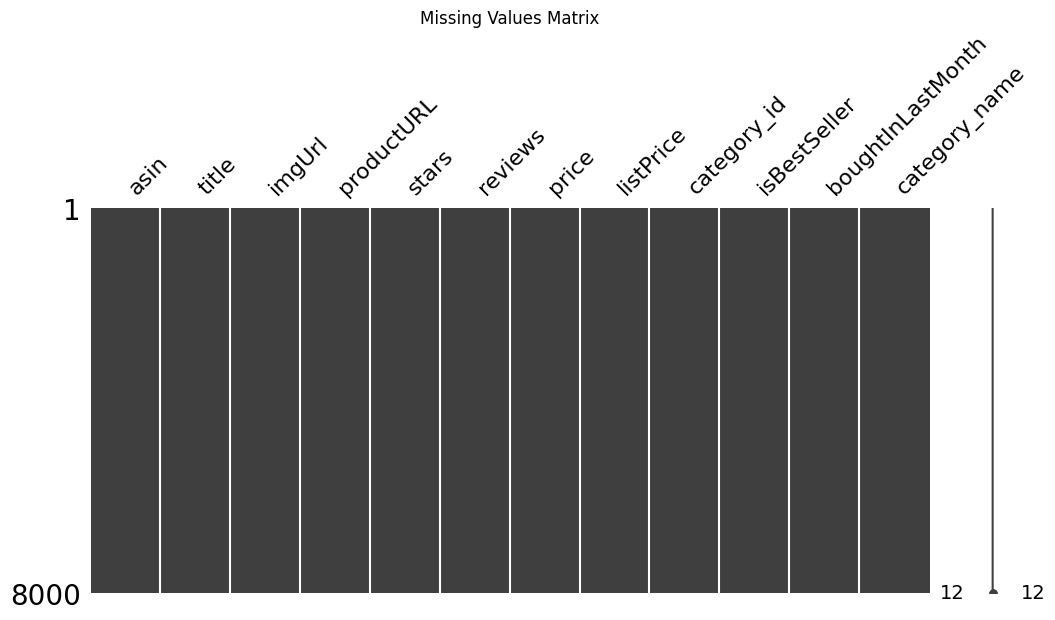

In [5]:
msno.matrix(df, figsize=(12, 5))
plt.title('Missing Values Matrix')
plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/missing_values_week2.png')
plt.show()

C:\Users\N I T R O 5\AppData\Local\Temp\ipykernel_14636\539977421.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


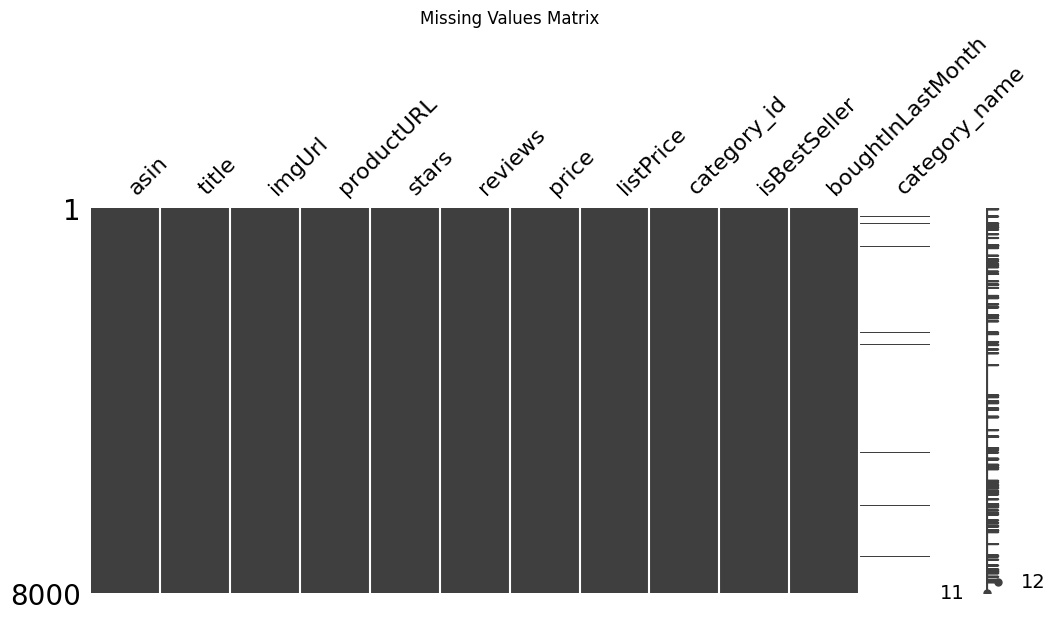

In [3]:
msno.matrix(df, figsize=(12, 5))
plt.title('Missing Values Matrix')
plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/missing_values_week2.png')
plt.show()

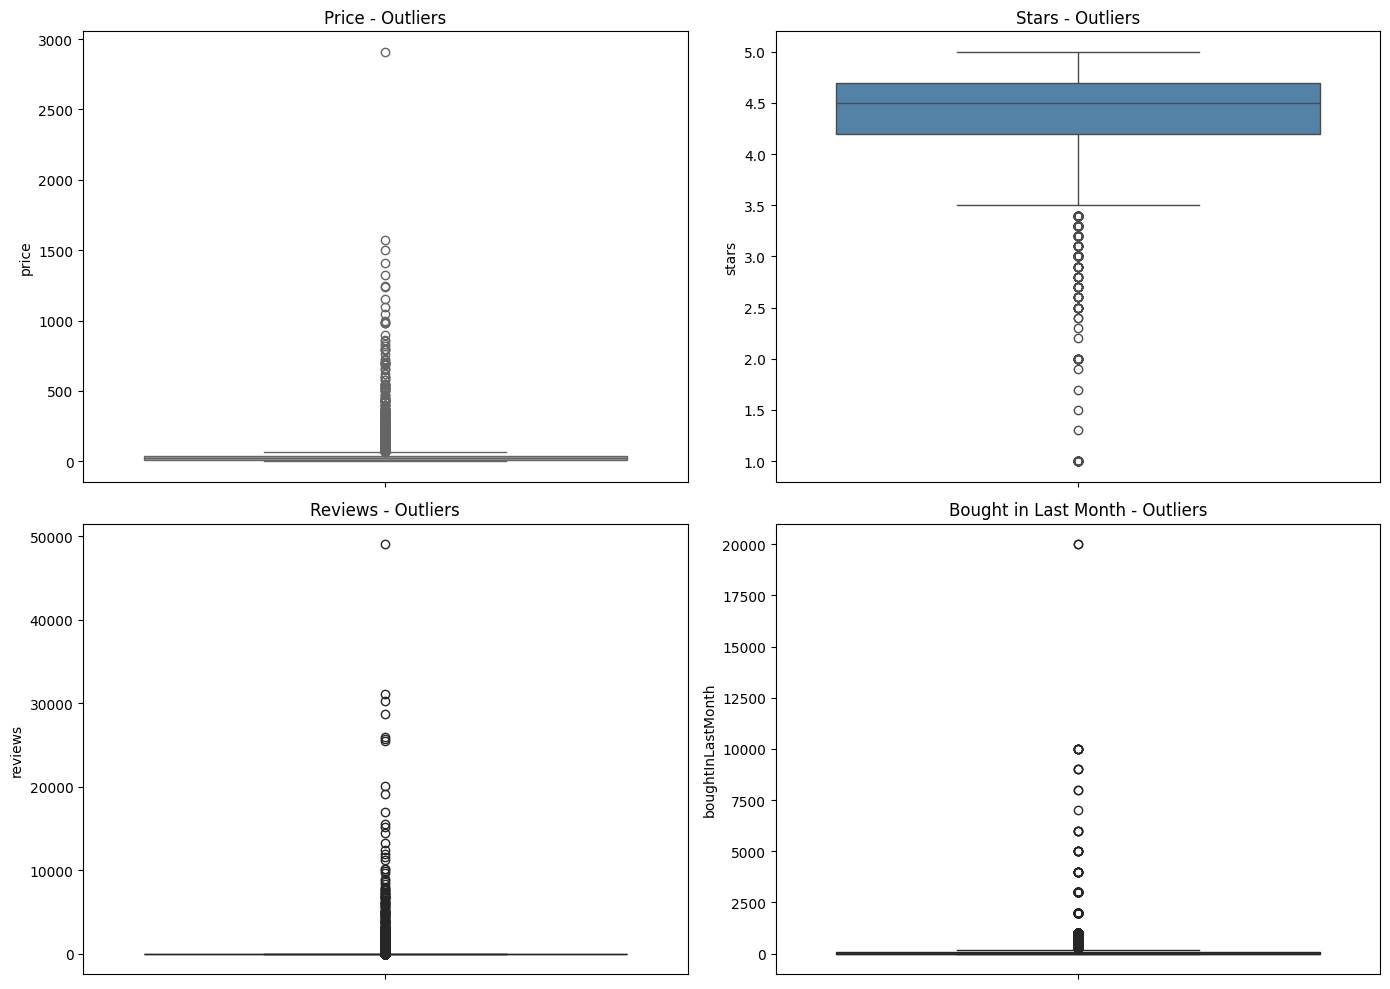

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=df['price'], ax=axes[0,0], color='coral')
axes[0,0].set_title('Price - Outliers')

sns.boxplot(y=df['stars'], ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Stars - Outliers')

sns.boxplot(y=df['reviews'], ax=axes[1,0], color='green')
axes[1,0].set_title('Reviews - Outliers')

sns.boxplot(y=df['boughtInLastMonth'], ax=axes[1,1], color='purple')
axes[1,1].set_title('Bought in Last Month - Outliers')

plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/outliers_boxplots.png')
plt.show()

In [7]:
def get_outlier_bounds(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={n_outliers} ({n_outliers/len(df)*100:.1f}%)")
    return lower, upper

for col in ['price', 'stars', 'reviews', 'boughtInLastMonth']:
    get_outlier_bounds(col)

price: lower=-22.51, upper=69.49, outliers=941 (11.8%)
stars: lower=3.45, upper=5.45, outliers=290 (3.6%)
reviews: lower=0.00, upper=0.00, outliers=1838 (23.0%)
boughtInLastMonth: lower=-150.00, upper=250.00, outliers=991 (12.4%)


In [8]:
price_cap = df['price'].quantile(0.99)
df['price_capped'] = np.where(df['price'] > price_cap, price_cap, df['price'])

reviews_cap = df['reviews'].quantile(0.99)
df['reviews_capped'] = np.where(df['reviews'] > reviews_cap, reviews_cap, df['reviews'])

print(f"Price cap (99th percentile): ${price_cap:.2f}")
print(f"Reviews cap (99th percentile): {reviews_cap:.0f}")
print(f"\nRows affected by price cap: {(df['price'] > price_cap).sum()}")
print(f"Rows affected by reviews cap: {(df['reviews'] > reviews_cap).sum()}")

Price cap (99th percentile): $390.03
Reviews cap (99th percentile): 4189

Rows affected by price cap: 80
Rows affected by reviews cap: 80


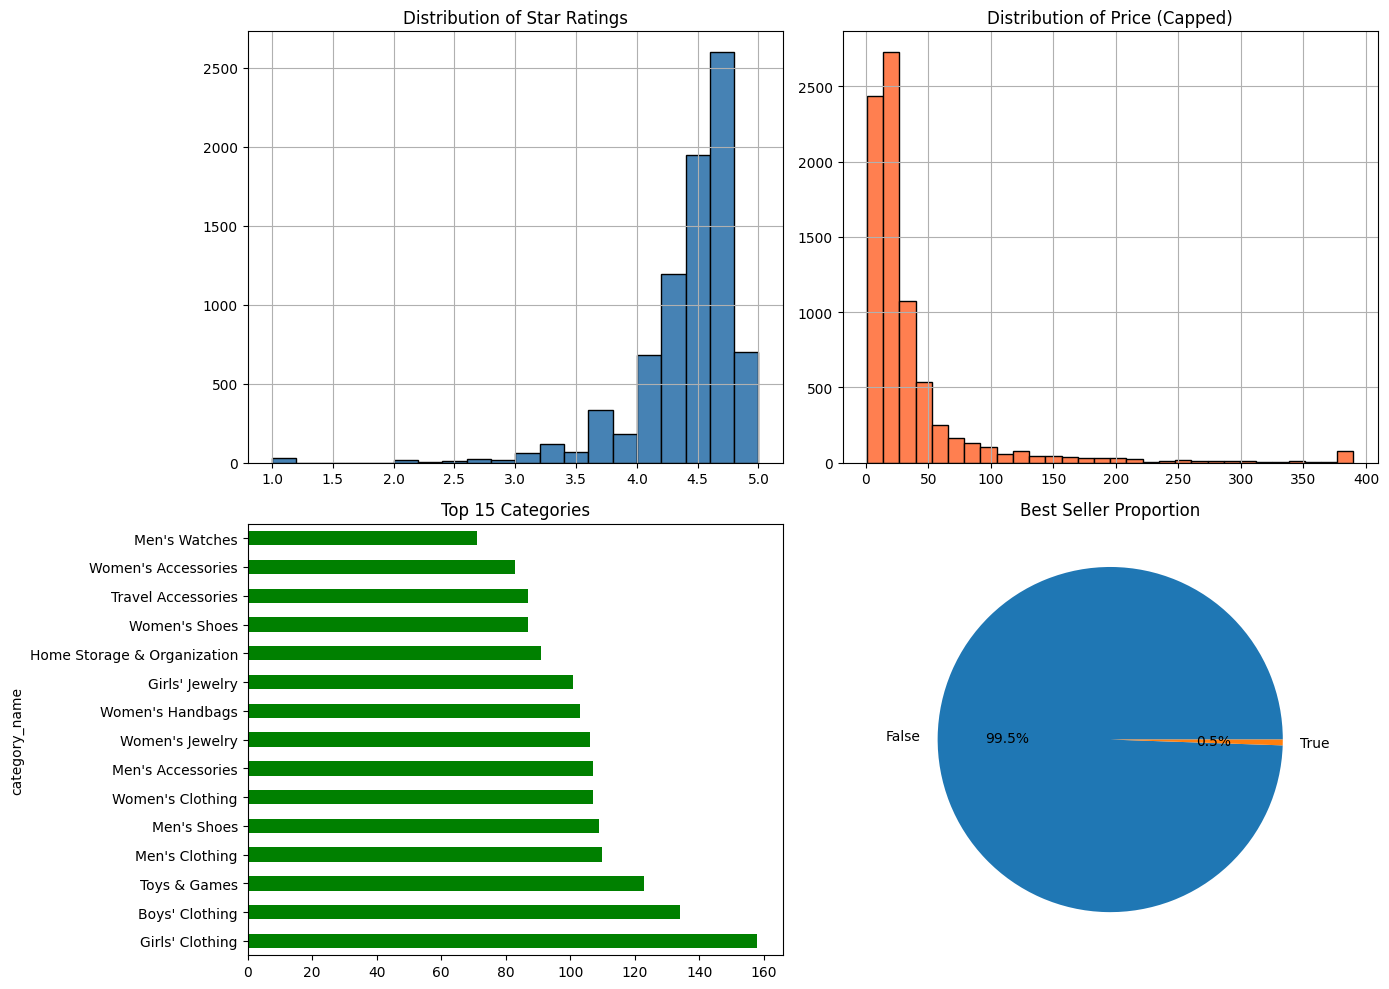

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['stars'].hist(bins=20, ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Star Ratings')

df['price_capped'].hist(bins=30, ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Distribution of Price (Capped)')

df['category_name'].value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='green')
axes[1,0].set_title('Top 15 Categories')

df['isBestSeller'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Best Seller Proportion')

plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/univariate_analysis.png')
plt.show()

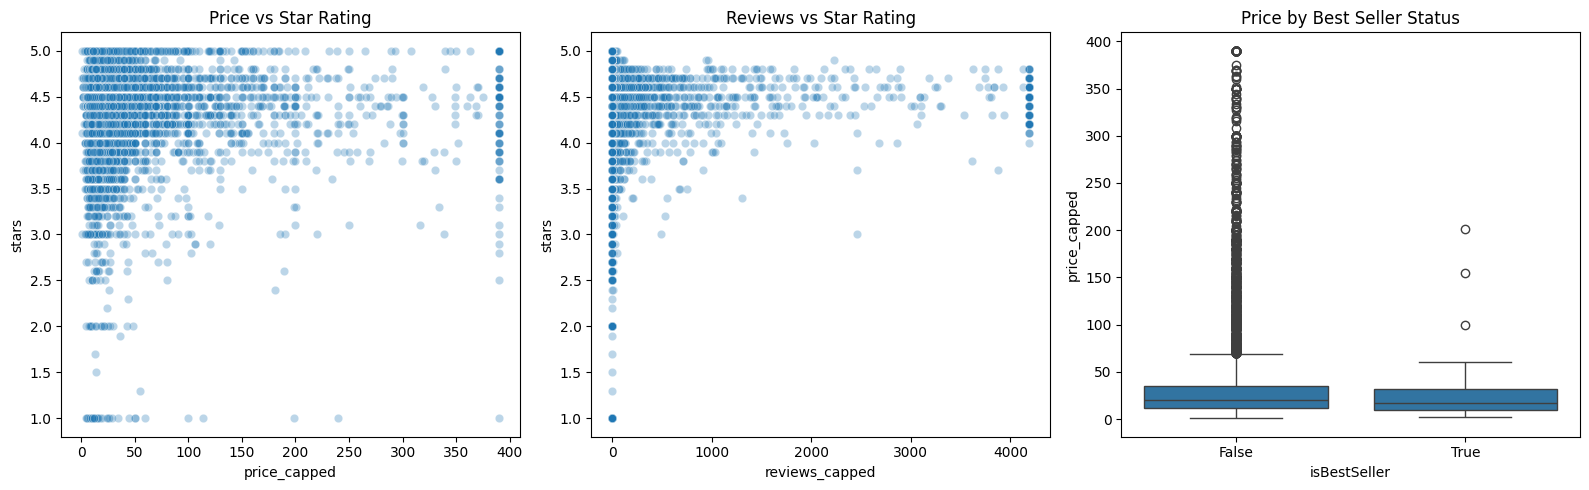

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x='price_capped', y='stars', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs Star Rating')

sns.scatterplot(data=df, x='reviews_capped', y='stars', alpha=0.3, ax=axes[1])
axes[1].set_title('Reviews vs Star Rating')

sns.boxplot(data=df, x='isBestSeller', y='price_capped', ax=axes[2])
axes[2].set_title('Price by Best Seller Status')

plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/bivariate_analysis.png')
plt.show()

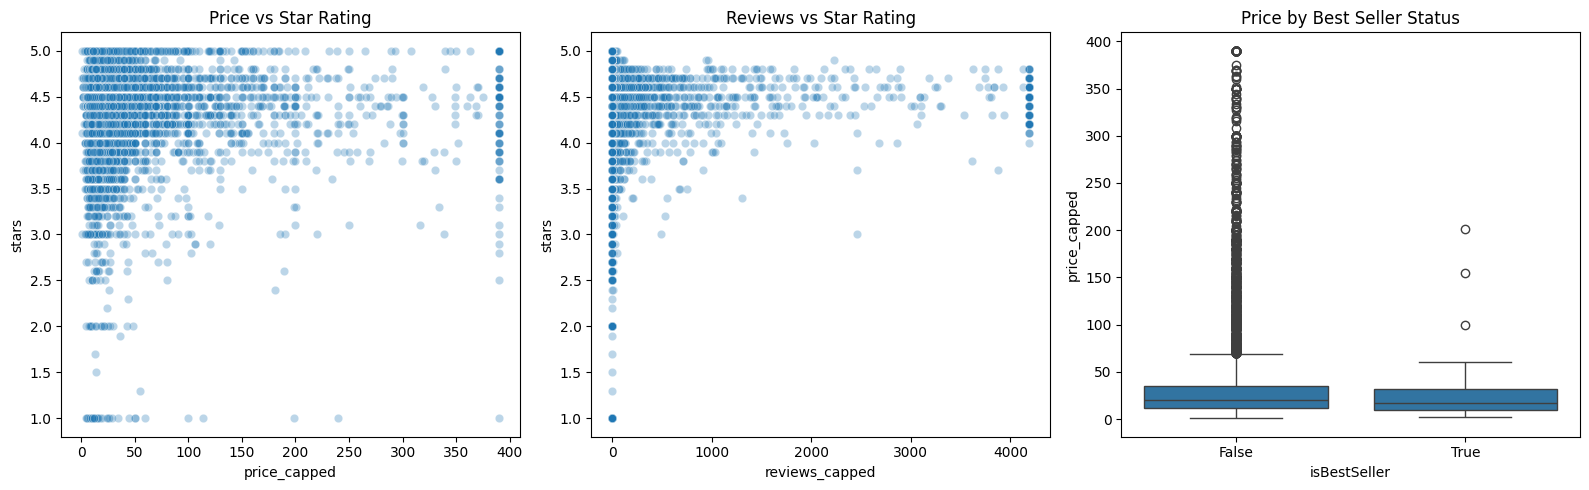

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x='price_capped', y='stars', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs Star Rating')

sns.scatterplot(data=df, x='reviews_capped', y='stars', alpha=0.3, ax=axes[1])
axes[1].set_title('Reviews vs Star Rating')

sns.boxplot(data=df, x='isBestSeller', y='price_capped', ax=axes[2])
axes[2].set_title('Price by Best Seller Status')

plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/bivariate_analysis.png')
plt.show()

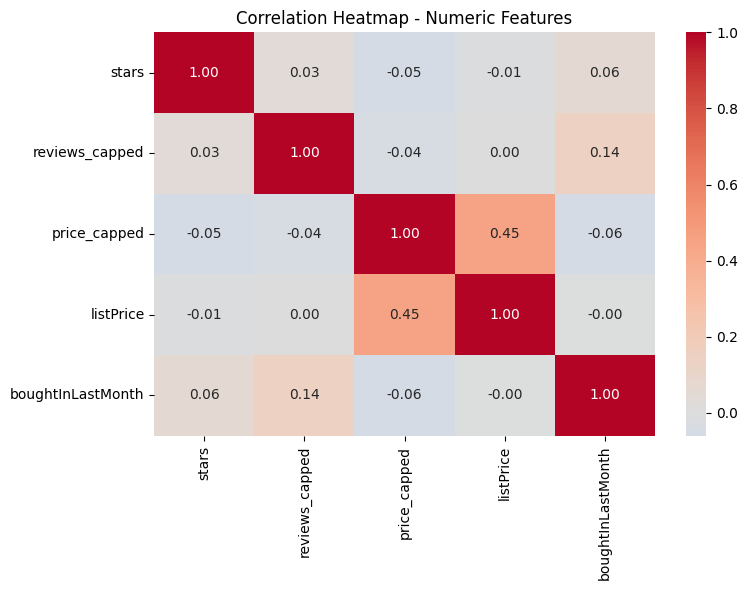

In [11]:
numeric_cols = ['stars', 'reviews_capped', 'price_capped', 'listPrice', 'boughtInLastMonth']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/correlation_heatmap.png')
plt.show()

count    8000.000000
mean       19.099125
std         8.551853
min         1.000000
25%        12.000000
50%        19.000000
75%        26.000000
max        48.000000
Name: title_length, dtype: float64


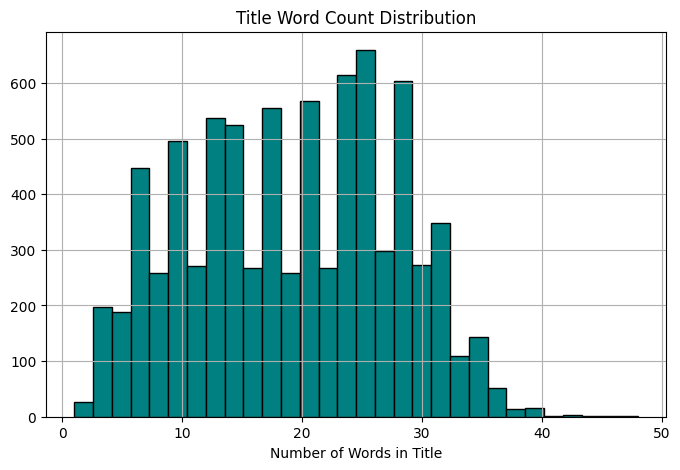


Products with very short titles (<4 words): 92


,title,category_name
74,Halo Reach,"Xbox 360 Games, Consoles & Accessories"
290,"Women's, Ontario Boot",Women's Shoes
347,Women's Lennon Mule,Women's Shoes
370,Men's Training Sneaker,Men's Shoes
389,Lego Maggie Simpson,Building Toys


In [12]:
df['title_length'] = df['title'].str.split().str.len()
print(df['title_length'].describe())

plt.figure(figsize=(8,5))
df['title_length'].hist(bins=30, color='teal', edgecolor='black')
plt.title('Title Word Count Distribution')
plt.xlabel('Number of Words in Title')
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/title_length_distribution.png')
plt.show()

short_titles = df[df['title_length'] < 4]
print(f"\nProducts with very short titles (<4 words): {len(short_titles)}")
short_titles[['title', 'category_name']].head()

In [13]:
df_cleaned = df.drop(columns=['title_length'])
df_cleaned.to_csv('D:/Semantic-Ecommerce-Recommender/data/processed/amazon_cleaned.csv', index=False)
print(f"Cleaned dataset saved: {df_cleaned.shape}")

Cleaned dataset saved: (8000, 14)


In [14]:
print("=== KEY NUMBERS FOR REPORT ===")
print(f"Total products: {len(df)}")
print(f"Total categories: {df['category_name'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nPrice cap (99th percentile): ${df['price'].quantile(0.99):.2f}")
print(f"Reviews cap (99th percentile): {df['reviews'].quantile(0.99):.0f}")
print(f"\nAverage star rating: {df['stars'].mean():.2f}")
print(f"Average price: ${df['price'].mean():.2f}")
print(f"\nShort titles (<4 words): {(df['title'].str.split().str.len() < 4).sum()}")
print(f"Average title length: {df['title'].str.split().str.len().mean():.1f} words")
print(f"\nTop correlation pair: price_capped vs listPrice = {df[['price_capped','listPrice']].corr().iloc[0,1]:.2f}")
print(f"\nBest Seller %: {(df['isBestSeller'].sum()/len(df)*100):.2f}%")

=== KEY NUMBERS FOR REPORT ===
Total products: 8000
Total categories: 248
Missing values: 0
Duplicate rows: 0

Price cap (99th percentile): $390.03
Reviews cap (99th percentile): 4189

Average star rating: 4.40
Average price: $41.19

Short titles (<4 words): 92
Average title length: 19.1 words

Top correlation pair: price_capped vs listPrice = 0.45

Best Seller %: 0.54%
